In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

MODELS = ["LR", "RF", "SVM", "XGB"]

In [2]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR     = PROJECT_ROOT / "data"

PRED_FILE = DATA_DIR / "05_scaling_no_ever_preds.csv"
OHE_FILE  = DATA_DIR / "05_data_OHE.csv"
OSTEO_FEATURES = DATA_DIR / "osteo_features.csv"

In [3]:
preds = pd.read_csv(PRED_FILE)

print("rows  :", len(preds))
print("strata:", preds["Strata"].nunique())
print("labels:", preds["osteo_label"].value_counts().to_dict())

assert len(preds) == 2 * preds["Strata"].nunique()

rows  : 61026
strata: 30513
labels: {0: 30513, 1: 30513}


# Check decision threshold

`pair_acc` says: for what fraction of matched pairs did the model give the case a higher probability than its own control?

`LR_prob` is one number per patient: the model's estimated probability that this patient is a case. It comes from `predict_proba` inside the fold loop in notebook 5, on the fold where that patient was held out. Every row in joined has one, whether the patient is actually a case or a control. No comparison involved — the model looks at one patient's features and outputs a number.

Then `PAIR_FRAME` reorganizes those numbers. It takes the two patients in a stratum, looks at their osteo_label, and files each one's `LR_prob` into a column named for what that patient actually is:

- the patient with `osteo_label` == 1 → their `LR_prob` becomes `case_prob`
- the patient with `osteo_label` == 0 → their `LR_prob` becomes `ctrl_prob`

Also worth noting: the names describe the true label, not the prediction. A `ctrl_prob` of 0.77 means a real control that the model scored high.

In [4]:
def PAIR_FRAME(preds, model):
    """One row per stratum: the case's probability and its matched control's."""
    wide = preds.pivot(index="Strata",
                       columns="osteo_label",
                       values=f"{model}_prob")
    wide.columns = ["ctrl_prob", "case_prob"]
    wide["margin"] = wide["case_prob"] - wide["ctrl_prob"]
    return wide


pairs = {m: PAIR_FRAME(preds, m) for m in MODELS}

# pairs[m]['margin']: turns the margin column into True/False. True where the case got the bigger number.
for m in MODELS:
    print(f"{m}: pair_acc = {(pairs[m]['margin'] > 0).mean():.4f}")

LR: pair_acc = 0.7469
RF: pair_acc = 0.7840
SVM: pair_acc = 0.7364
XGB: pair_acc = 0.7865


`.mean()` on a True/False column gives the fraction that are True, because True counts as 1 and False as 0. Over 30,513 strata, XGB gives 0.7865.
So: in 78.65% of pairs the model gave the case a higher probability than its matched control. In the remaining 21.35% it gave the control the higher one.

In [5]:
for m in MODELS:
    print(m)
    print(pairs[m].describe())
    print('\n')

LR
          ctrl_prob     case_prob        margin
count  30513.000000  30513.000000  30513.000000
mean       0.397767      0.602192      0.204425
std        0.151786      0.238567      0.285293
min        0.010945      0.003650     -0.892382
25%        0.306113      0.405389     -0.000816
50%        0.399617      0.534027      0.171894
75%        0.451724      0.861473      0.447104
max        0.999012      0.999927      0.954271


RF
          ctrl_prob     case_prob        margin
count  30513.000000  30513.000000  30513.000000
mean       0.378299      0.620297      0.241999
std        0.149682      0.242310      0.286053
min        0.027819      0.043809     -0.830416
25%        0.298593      0.402504      0.017690
50%        0.366812      0.570893      0.208270
75%        0.455656      0.875008      0.482377
max        0.989251      0.998064      0.952391


SVM
          ctrl_prob     case_prob        margin
count  30513.000000  30513.000000  30513.000000
mean       0.413955      0

# predicted-probability distribution by class — that shows how the two classes overlap

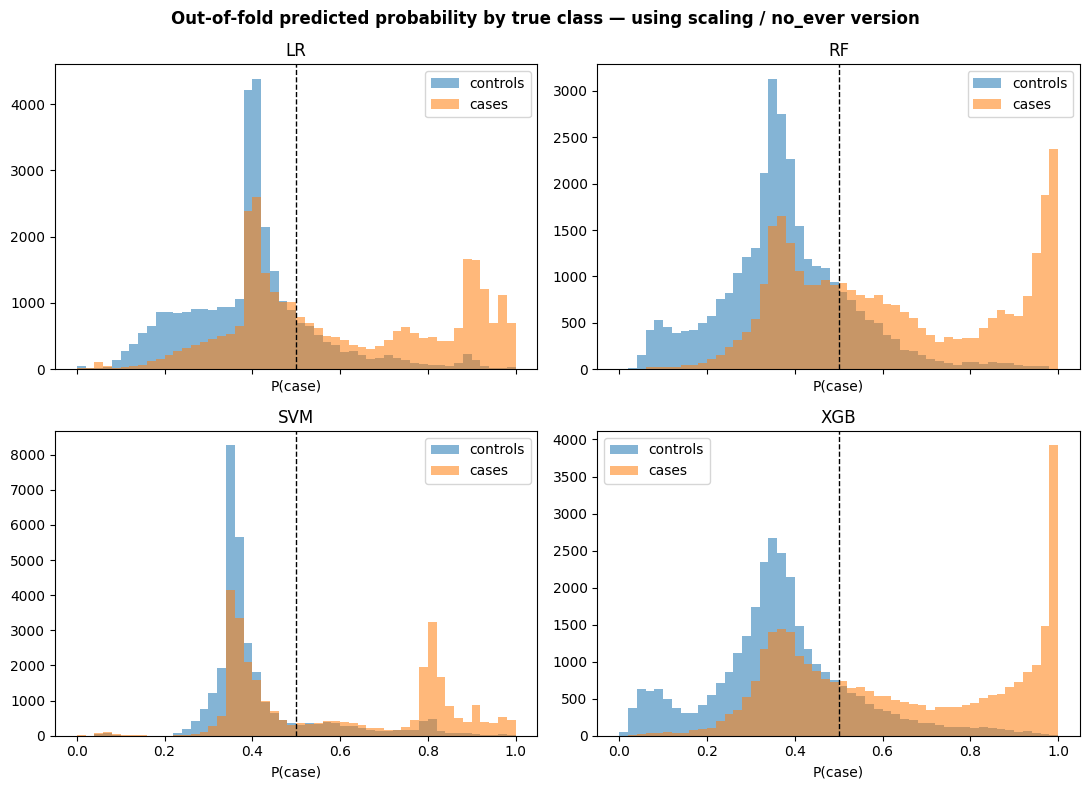

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True)

for ax, m in zip(axes.ravel(), MODELS):
    for label, name in [(0, "controls"), (1, "cases")]:
        ax.hist(preds.loc[preds["osteo_label"] == label, f"{m}_prob"],
                bins=50, range=(0, 1), alpha=0.55, label=name)
    ax.axvline(0.5, color="k", linestyle="--", linewidth=1)
    ax.set_title(m)
    ax.set_xlabel("P(case)")
    ax.legend()

fig.suptitle("Out-of-fold predicted probability by true class — using scaling / no_ever version",
             fontweight="bold")
fig.tight_layout()
plt.show()

The x-axis is `P(case)`, the model's output for each row. clf.predict turns that into a label by one rule: probability above 0.5 → predict case (1), below → predict control (0). The dashed line drawn at 0.5 is that rule made visible. So a row's horizontal position, relative to that line, is its prediction.

Now put the true labels back in. **Color is truth** — orange rows are actually cases, blue rows are actually controls. Position is the prediction. So each of the four combinations is a cell of the confusion matrix:

- orange, right of line → true case, predicted case → correct or `TP`
- orange, left of line → true case, predicted control → miss or `FN`
- blue, left of line → true control, predicted control → correct or `TN`
- blue, right of line → true control, predicted case → false alarm or `FP`

- `Case recall` is the orange mass right of the line divided by all orange mass.
- `Control recall` is the blue mass left of the line divided by all blue mass.

`Controls` form one tight **unimodal** cluster around 0.35–0.40. `Cases` split into two groups: one overlapping the `control` cluster almost exactly, and a second at the high end — 0.9+ in LR and XGB, 0.8 in SVM, pinned at 1.0 in RF.

In [7]:
summary = []
for m in MODELS:
    for label, name in [(1, "cases"), (0, "controls")]:
        p = preds.loc[preds["osteo_label"] == label, f"{m}_prob"]
        summary.append({"model": m, "class": name,
                        "median": p.median(),
                        "q25": p.quantile(0.25),
                        "q75": p.quantile(0.75),
                        "frac_above_0.5": (p > 0.5).mean()})

print(pd.DataFrame(summary).set_index(["model", "class"]).round(3))

                median    q25    q75  frac_above_0.5
model class                                         
LR    cases      0.534  0.405  0.861           0.542
      controls   0.400  0.306  0.452           0.170
RF    cases      0.571  0.403  0.875           0.599
      controls   0.367  0.299  0.456           0.176
SVM   cases      0.521  0.370  0.808           0.512
      controls   0.366  0.350  0.416           0.162
XGB   cases      0.587  0.394  0.909           0.593
      controls   0.358  0.284  0.443           0.169


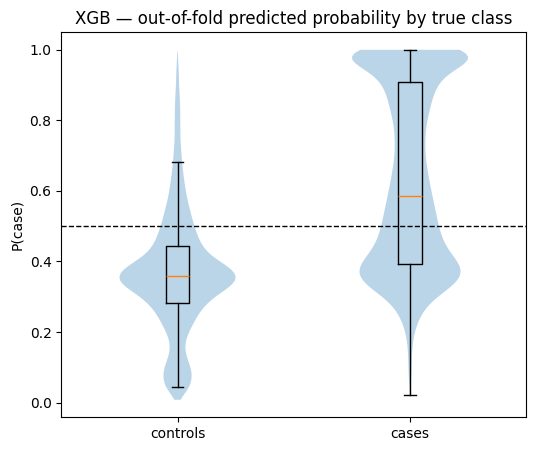

In [8]:
fig, ax = plt.subplots(figsize=(6, 5))

groups = [preds.loc[preds["osteo_label"] == 0, "XGB_prob"],
          preds.loc[preds["osteo_label"] == 1, "XGB_prob"]]

parts = ax.violinplot(groups, showextrema=False)
ax.boxplot(groups, widths=0.1, showfliers=False)

ax.set_xticks([1, 2])
ax.set_xticklabels(["controls", "cases"])
ax.set_ylabel("P(case)")
ax.axhline(0.5, color="k", linestyle="--", linewidth=1)
ax.set_title("XGB — out-of-fold predicted probability by true class")

plt.show()

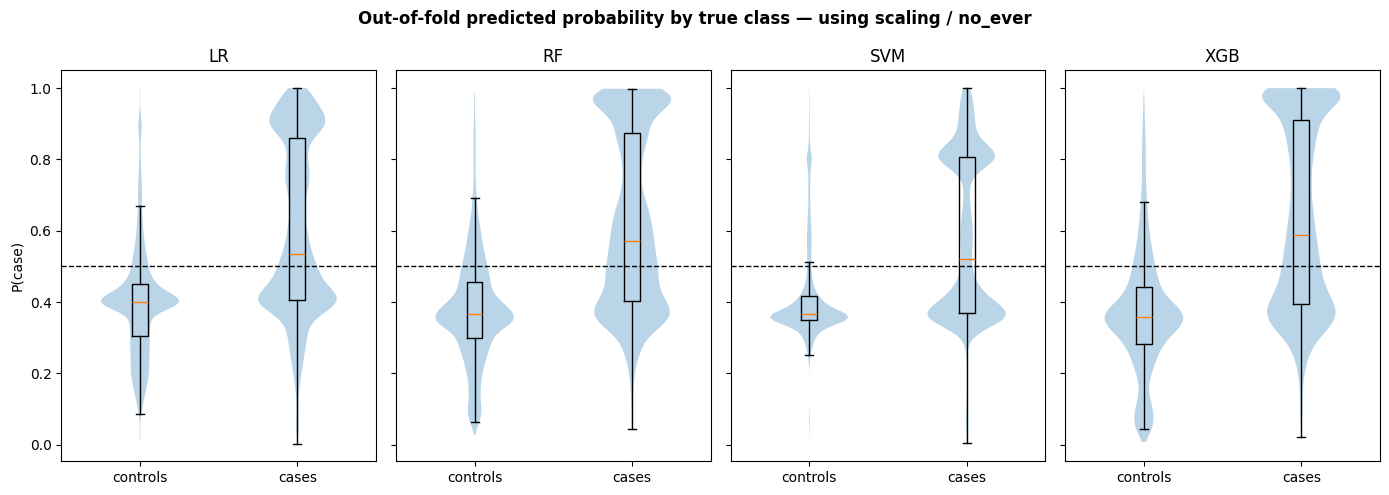

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(14, 5), sharey=True)

for ax, m in zip(axes, MODELS):
    groups = [preds.loc[preds["osteo_label"] == 0, f"{m}_prob"],
              preds.loc[preds["osteo_label"] == 1, f"{m}_prob"]]

    ax.violinplot(groups, showextrema=False)
    ax.boxplot(groups, widths=0.1, showfliers=False)

    ax.set_xticks([1, 2])
    ax.set_xticklabels(["controls", "cases"])
    ax.axhline(0.5, color="k", linestyle="--", linewidth=1)
    ax.set_title(m)

axes[0].set_ylabel("P(case)")
fig.suptitle("Out-of-fold predicted probability by true class — using scaling / no_ever",
             fontweight="bold")
fig.tight_layout()
plt.show()

> The cases are bimodal in every model. The controls are not.

> What we have is a subgroup of cases the models identify confidently and a subgroup they can't distinguish from controls at all.

# what separates the two `case` modes?

In [11]:
probs = [f"{m}_prob" for m in MODELS]  # Uses brackets [] instead of parentheses ()
print(preds[probs])

        LR_prob   RF_prob  SVM_prob  XGB_prob
0      0.388075  0.411468  0.350582  0.406913
1      0.385053  0.366629  0.346666  0.373803
2      0.392603  0.409113  0.366122  0.404948
3      0.520225  0.450823  0.411164  0.468966
4      0.770783  0.569091  0.770909  0.771894
...         ...       ...       ...       ...
61021  0.809451  0.630349  0.657561  0.816994
61022  0.332481  0.467732  0.560151  0.422588
61023  0.388368  0.326922  0.350735  0.334260
61024  0.369457  0.451662  0.354943  0.481590
61025  0.480282  0.499825  0.406893  0.496347

[61026 rows x 4 columns]


In [13]:
data_OHE = pd.read_csv(OHE_FILE)

FEATURE_COLS = [c for c in data_OHE.columns
                if c not in ("Strata", "osteo_label")]

joined = data_OHE.merge(
    preds[["Strata", "osteo_label"] + [f"{m}_prob" for m in MODELS]],
    on=["Strata", "osteo_label"],
    validate="one_to_one",
)

print(joined.shape, len(FEATURE_COLS), "features")

(61026, 55) 49 features


In [14]:
joined

,Strata,osteo_label,BMI_Avg,Alcohol_Prior,Tobacco_Prior,Drug_antipsych_prior,Drug_Estrogens_prior,Drug_Glucocorticoids_prior,Drug_Nsaids_prior,Drug_Opiates_prior,...,Race_Cat_combine_white,Age_combine_from_30_to_50,Age_combine_from_50_to_70,Age_combine_from_70_to_80,Age_combine_less_than_30,Age_combine_more_than_80,LR_prob,RF_prob,SVM_prob,XGB_prob
0,9576,0,37.834028,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0.388075,0.411468,0.350582,0.406913
1,13833,0,32.948625,0,0,0,0,0,0,0,...,1,0,0,1,0,0,0.385053,0.366629,0.346666,0.373803
2,28858,0,33.388021,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0.392603,0.409113,0.366122,0.404948
3,16496,0,28.308928,1,0,0,0,0,0,0,...,0,0,1,0,0,0,0.520225,0.450823,0.411164,0.468966
4,1,1,22.666667,0,0,1,0,0,0,1,...,1,0,0,0,0,1,0.770783,0.569091,0.770909,0.771894
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61021,10014,0,21.018420,0,1,0,0,0,0,1,...,1,1,0,0,0,0,0.809451,0.630349,0.657561,0.816994
61022,30515,1,23.306191,0,1,0,0,0,0,1,...,1,0,1,0,0,0,0.332481,0.467732,0.560151,0.422588
61023,30516,1,29.867651,0,0,0,0,0,0,0,...,1,0,0,1,0,0,0.388368,0.326922,0.350735,0.334260
61024,30517,1,14.383965,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0.369457,0.451662,0.354943,0.481590


In [15]:
MODEL = "XGB"
CUT   = 0.6          # the trough between the two case modes

cases = joined[joined["osteo_label"] == 1].copy()
cases["mode"] = np.where(cases[f"{MODEL}_prob"] >= CUT, "high confidence", "low confidence") #high mean the model confident about its prediction

print(cases["mode"].value_counts().to_dict())

{'low confidence': 15615, 'high confidence': 14898}


In [16]:
cases

,Strata,osteo_label,BMI_Avg,Alcohol_Prior,Tobacco_Prior,Drug_antipsych_prior,Drug_Estrogens_prior,Drug_Glucocorticoids_prior,Drug_Nsaids_prior,Drug_Opiates_prior,...,Age_combine_from_30_to_50,Age_combine_from_50_to_70,Age_combine_from_70_to_80,Age_combine_less_than_30,Age_combine_more_than_80,LR_prob,RF_prob,SVM_prob,XGB_prob,mode
4,1,1,22.666667,0,0,1,0,0,0,1,...,0,0,0,0,1,0.770783,0.569091,0.770909,0.771894,high confidence
5,2,1,32.628159,0,0,0,0,0,1,0,...,0,0,1,0,0,0.447488,0.462643,0.429584,0.389679,low confidence
7,3,1,32.916889,0,0,0,0,0,0,0,...,0,0,1,0,0,0.266590,0.355639,0.341122,0.333437,low confidence
8,4,1,35.349977,0,0,0,0,0,0,0,...,0,1,0,0,0,0.439679,0.513849,0.375097,0.479924,low confidence
12,5,1,30.346668,0,0,0,0,0,0,0,...,0,0,1,0,0,0.382123,0.333034,0.346657,0.343354,low confidence
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61016,30513,1,36.731561,0,1,0,0,0,0,0,...,1,0,0,0,0,0.451814,0.428232,0.408987,0.489289,low confidence
61017,30514,1,21.400000,0,0,0,0,0,1,1,...,0,0,1,0,0,0.797754,0.682479,0.908270,0.839537,high confidence
61022,30515,1,23.306191,0,1,0,0,0,0,1,...,0,1,0,0,0,0.332481,0.467732,0.560151,0.422588,low confidence
61023,30516,1,29.867651,0,0,0,0,0,0,0,...,0,0,1,0,0,0.388368,0.326922,0.350735,0.334260,low confidence


In [17]:
FEATURE_COLS = [c for c in data_OHE.columns
                if c not in ("Strata", "osteo_label")
                and "_Ever" not in c]

#among the cases that XGB predicted
compare = (cases.groupby("mode")[FEATURE_COLS]
                .mean()
                .T
                .assign(diff=lambda d: d["high confidence"] - d["low confidence"]))

print(compare.reindex(compare["diff"].abs().sort_values(ascending=False).index)
             .head(15).round(3))

mode                            high confidence  low confidence   diff
Calcium_Avg_Prior_decile                  2.050           3.082 -1.032
Calcium_Closest_Osteo_decile              2.023           2.837 -0.814
BMI_Avg                                  27.225          27.961 -0.736
Sodium_Closest_Osteo_decile               2.820           2.437  0.383
Calcium_Closest_Osteo_measured            0.386           0.624 -0.238
Calcium_Avg_Prior_measured                0.410           0.619 -0.209
Sodium_Closest_Osteo_measured             0.828           0.624  0.204
Sodium_Avg_Prior_decile                   3.074           2.910  0.163
Hyponatremia_Prior                        0.230           0.092  0.138
Sodium_Worst_Prior_measured               0.754           0.619  0.135
Sodium_Avg_Prior_measured                 0.754           0.619  0.135
Chronic_Hyponatremia                      0.133           0.013  0.120
Recent_Hyponatremia                       0.148           0.030  0.118
Drug_O

You split the `cases` that XGB predicted into two groups by predicted probability — 14,898 "high" and 15,615 "low". Read the two columns:

Sodium measured in `Sodium_Closest_Osteo_measured`: high 0.828, low 0.624. 
- Among cases the model scores confidently, 83% had a sodium drawn.
- Among cases it can't distinguish from controls, 62% did.
  
Calcium measured in `Calcium_Closest_Osteo_measured`: high 0.386, low 0.624. Only 39% of the confident group had a calcium drawn, versus 62% of the other group.

> the thing distinguishing these two groups of cases is which tests a clinician ordered, not what the results were.

In [18]:
MEASURED_COLS = [c for c in data_OHE.columns
                 if c.endswith("_measured")
                 and "_Ever" not in c]

compare_measured = (cases.groupby("mode")[MEASURED_COLS]
                         .mean()
                         .T
                         .assign(diff=lambda d: d["high confidence"] - d["low confidence"]))

print(compare_measured.reindex(
          compare_measured["diff"].abs().sort_values(ascending=False).index)
      .round(3))

mode                            high confidence  low confidence   diff
Calcium_Closest_Osteo_measured            0.386           0.624 -0.238
Calcium_Avg_Prior_measured                0.410           0.619 -0.209
Sodium_Closest_Osteo_measured             0.828           0.624  0.204
Sodium_Avg_Prior_measured                 0.754           0.619  0.135
Sodium_Worst_Prior_measured               0.754           0.619  0.135


> Calcium is measured less often in the high-confidence cases
> 
> Sodium is measured more often in high-confidence cases

The low-confidence column is nearly constant. 0.624, 0.619, 0.624, 0.619, 0.619 across all five. Whatever the ordering process is, the cases the model can't identify look the same on every measurement flag — roughly 62% have each test. The high-confidence column is the one that varies, from 0.386 up to 0.828.

Two sodium columns are identical. Sodium_Avg_Prior_measured and Sodium_Worst_Prior_measured match to three decimals in both groups (0.754 / 0.619). Both derive from the same prior-window sodium draws, so a patient with any prior sodium has both an average and a worst — they're the same flag under two names. That's a redundant feature pair, and worth noting for the leakage/column audit since it means one of them carries no information the other doesn't.

In [19]:
print(joined.groupby("Calcium_Avg_Prior_measured")["Calcium_Avg_Prior_decile"]
            .describe().round(3))

                              count   mean    std  min  25%  50%  75%  max
Calcium_Avg_Prior_measured                                                
0                           25388.0  0.000  0.000  0.0  0.0  0.0  0.0  0.0
1                           35638.0  4.468  2.849  0.0  2.0  4.0  7.0  9.0


### Among `cases` who actually had lab draw

In [21]:
DECILES = [c for c in FEATURE_COLS if c.endswith("_decile")]

for col in DECILES:
    flag = col.replace("_decile", "_measured")
    sub = cases[cases[flag] == 1]
    g = sub.groupby("mode")[col].mean()
    print(f"{col:36s} high {g['high confidence']:.3f}  low {g['low confidence']:.3f}  "
          f"diff {g['high confidence'] - g['low confidence']:+.3f}")

Calcium_Closest_Osteo_decile         high 5.244  low 4.550  diff +0.694
Sodium_Closest_Osteo_decile          high 3.406  low 3.904  diff -0.498
Calcium_Avg_Prior_decile             high 5.003  low 4.977  diff +0.026
Sodium_Avg_Prior_decile              high 4.078  low 4.701  diff -0.622
Sodium_Worst_Prior_decile            high 3.421  low 4.341  diff -0.920


### check lab results for those who actually had lab draw

In [22]:
osteo_features = pd.read_csv(OSTEO_FEATURES)
osteo_features.shape

/var/folders/dq/3x7mwtv514n94gkw_yqvzj040000gn/T/ipykernel_13780/2658473009.py:1: DtypeWarning: Columns (0: First_Chemo_agent_date) have mixed types. Specify dtype option on import or set low_memory=False.
  osteo_features = pd.read_csv(OSTEO_FEATURES)


(61026, 203)

In [23]:
RAW_LABS = ["Calcium_Avg_Prior",    "Calcium_Closest_Osteo",
             "Sodium_Worst_Prior", "Sodium_Avg_Prior", "Sodium_Closest_Osteo"
           ]

raw = pd.read_csv(OSTEO_FEATURES, usecols=["Strata", "osteo_label"] + RAW_LABS)

print(raw.shape)
print(raw.duplicated(["Strata", "osteo_label"]).sum(), "duplicate keys")

(61026, 7)
0 duplicate keys


In [24]:
joined = joined.merge(raw, on=["Strata", "osteo_label"], validate="one_to_one")
print(joined.shape)

(61026, 60)


In [25]:
joined.head()

,Strata,osteo_label,BMI_Avg,Alcohol_Prior,Tobacco_Prior,Drug_antipsych_prior,Drug_Estrogens_prior,Drug_Glucocorticoids_prior,Drug_Nsaids_prior,Drug_Opiates_prior,...,Age_combine_more_than_80,LR_prob,RF_prob,SVM_prob,XGB_prob,Calcium_Closest_Osteo,Calcium_Avg_Prior,Sodium_Closest_Osteo,Sodium_Avg_Prior,Sodium_Worst_Prior
0,9576,0,37.834028,0,0,0,0,0,0,0,...,0,0.388075,0.411468,0.350582,0.406913,NaN,NaN,NaN,NaN,NaN
1,13833,0,32.948625,0,0,0,0,0,0,0,...,0,0.385053,0.366629,0.346666,0.373803,NaN,NaN,NaN,NaN,NaN
2,28858,0,33.388021,0,0,0,0,0,0,0,...,0,0.392603,0.409113,0.366122,0.404948,NaN,NaN,NaN,NaN,NaN
3,16496,0,28.308928,1,0,0,0,0,0,0,...,0,0.520225,0.450823,0.411164,0.468966,10.2,10.200000,144.0,144.000000,144.0
4,1,1,22.666667,0,0,1,0,0,0,1,...,1,0.770783,0.569091,0.770909,0.771894,8.3,9.666667,145.0,141.142857,138.0


In [26]:
joined = joined.drop(columns=[c for c in joined.columns if c.endswith("_y")])
joined.columns = [c[:-2] if c.endswith("_x") else c for c in joined.columns]

print(joined.shape)

(61026, 60)


In [27]:
# cases was built from joined BEFORE the raw labs were merged in, so rebuild it
cases = joined[joined["osteo_label"] == 1].copy()
cases["mode"] = np.where(cases[f"{MODEL}_prob"] >= CUT, "high confidence", "low confidence")

for col in RAW_LABS:
    sub = cases[cases[f"{col}_measured"] == 1]
    g = sub.groupby("mode")[col]
    print(f"\n=== {col} ===")
    print(g.agg(["count", "mean", "median", "std"]).round(2))


=== Calcium_Avg_Prior ===
                 count  mean  median   std
mode                                      
high confidence   6105  9.13    9.15  0.83
low confidence    9670  9.10    9.17  0.68

=== Calcium_Closest_Osteo ===
                 count  mean  median   std
mode                                      
high confidence   5747  9.27     9.3  1.27
low confidence    9736  9.06     9.2  0.78

=== Sodium_Worst_Prior ===
                 count    mean  median    std
mode                                         
high confidence  11228  136.37   137.0  11.24
low confidence    9668  137.81   138.0   4.49

=== Sodium_Avg_Prior ===
                 count    mean  median    std
mode                                         
high confidence  11228  139.02   139.4  10.74
low confidence    9668  139.75   140.0   3.58

=== Sodium_Closest_Osteo ===
                 count    mean  median    std
mode                                         
high confidence  12333  138.59   139.0  10.59
low conf

In [28]:
for col in RAW_LABS:
    dec = f"{col}_decile"
    #only include patients w lab draw (thus measure==1). meaning exclude unmeasured patients here
    g = joined[joined[f"{col}_measured"] == 1].groupby(dec)[col]
    print(f"\n=== {col} ===")
    print(g.agg(["count", "min", "mean", "max"]).round(2))


=== Calcium_Avg_Prior ===
                          count   min   mean    max
Calcium_Avg_Prior_decile                           
0                          3564  0.75   6.17   7.78
1                          3564  7.78   8.10   8.35
2                          3574  8.35   8.50   8.64
3                          3560  8.64   8.76   8.87
4                          3559  8.87   8.96   9.05
5                          3723  9.06   9.14   9.20
6                          4207  9.20   9.32   9.40
7                          2760  9.40   9.50   9.58
8                          3725  9.58   9.69   9.80
9                          3402  9.80  10.17  37.40

=== Calcium_Closest_Osteo ===
                              count   min   mean   max
Calcium_Closest_Osteo_decile                          
0                              3631   0.6   4.46   7.8
1                              4434   7.9   8.19   8.4
2                              3833   8.5   8.61   8.7
3                              3217   8.8  

## Check if missingness by class becoming the predictive signal — showing up as within-class structure rather than between-class

#### Between-class table - Question: do cases get different labs ordered than controls?

Between-class — split by osteo_label. All cases in one group, all controls in the other. 

Question: **do cases get different labs ordered than controls?**

In [31]:
MEASURED = [c for c in FEATURE_COLS if c.endswith("_measured")]

between = joined.groupby("osteo_label")[MEASURED].mean().T
between.columns = ["controls", "cases"]
between["diff"] = between["cases"] - between["controls"]

between = between.sort_index()

between = between.reindex(
    sorted(between.index, key=lambda c: (c.split("_")[0], c))
)

print(between.round(3))

                                controls  cases   diff
Calcium_Avg_Prior_measured         0.651  0.517 -0.134
Calcium_Closest_Osteo_measured     0.658  0.507 -0.151
Sodium_Avg_Prior_measured          0.663  0.685  0.022
Sodium_Closest_Osteo_measured      0.672  0.724  0.052
Sodium_Worst_Prior_measured        0.663  0.685  0.022


> **Between-class observation**: the signal is real but weak. Calcium is drawn less often in cases (0.51 vs 0.66) and sodium slightly more (0.72 vs 0.67). No single flag separates cases from controls.

#### Within class table

- Within-class — throw the controls away entirely. Take only the cases, and split those by whether XGB scored them above or below 0.6. 
- Question: **among patients who are all cases, do the ones the model recognizes get different labs than the ones it misses?**

In [35]:
within = cases.groupby("mode")[MEASURED].mean().T
within["diff"] = within["high confidence"] - within["low confidence"]

within = within.sort_index()

print(within.round(3))

mode                            high confidence  low confidence   diff
Calcium_Avg_Prior_measured                0.410           0.619 -0.209
Calcium_Closest_Osteo_measured            0.386           0.624 -0.238
Sodium_Avg_Prior_measured                 0.754           0.619  0.135
Sodium_Closest_Osteo_measured             0.828           0.624  0.204
Sodium_Worst_Prior_measured               0.754           0.619  0.135


> **Within-class observation**: the same five flags, but the gaps are larger — 0.135 to 0.238, roughly 1.5× the between-class gaps, and in the same directions. So the measurement flags carry more information about which cases the model can identify than about whether a patient is a case.

### Conclusion — missingness is within-class structure, not between-class

**Between-class (cell above): real but weak.** Calcium is drawn *less* often in cases
(0.51 vs. 0.66) and sodium slightly *more* (0.72 vs. 0.67). Gaps of 0.02–0.15. No single
flag separates cases from controls.

**Within-class: same five flags, larger gaps.** 0.135–0.238, roughly 1.5x the
between-class gaps, in the same directions. The measurement flags carry more information
about *which cases the model can identify* than about *whether a patient is a case*.
